<a href="https://colab.research.google.com/github/Sansebastian318/Mecanica/blob/main/primera_idea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_26369/2850892037.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0208
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0018
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0016
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0014
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0012
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0012
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0012
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 9.2585e-04
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 8.2970e-04
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 7.8315e-04
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 7.3002e-04
Epoch 12/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 7.4762e-04
Epoch 13/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 7.2046e-04
Epoch 14/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 6.1855e-04
Epoch 15/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 6

ValueError: could not broadcast input array from shape (426,1) into shape (365,1)

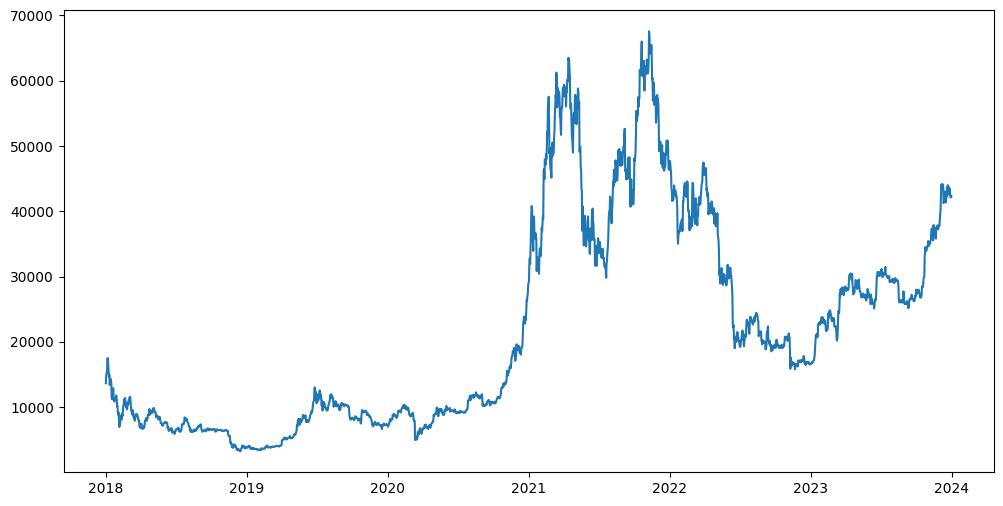

In [ ]:
# =========================
# 1. LIBRERÍAS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import yfinance as yf


# =========================
# 2. DESCARGAR DATOS
# =========================
btc = yf.download("BTC-USD", start="2016-01-01", end="2026-01-01")

data = btc[['Close']]
data.head()


# =========================
# 3. NORMALIZAR DATOS
# =========================
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


# =========================
# 4. CREAR SECUENCIAS
# =========================
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)


# =========================
# 5. DIVIDIR DATOS
# =========================
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# reshape para LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


# =========================
# 6. CREAR MODELO LSTM
# =========================
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')


# =========================
# 7. ENTRENAR
# =========================
model.fit(X_train, y_train, epochs=20, batch_size=32)


# =========================
# 8. PREDICCIONES
# =========================
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# desnormalizar
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_real = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))


# =========================
# 9. MÉTRICAS (MSE y RMSE)
# =========================
mse = mean_squared_error(y_test_real, test_predict)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)


# =========================
# 10. GRÁFICA
# =========================
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label="Real")

# Ajustar predicciones
train_plot = np.empty_like(scaled_data)
train_plot[:] = np.nan
train_plot[time_step:len(train_predict)+time_step] = train_predict

test_plot = np.empty_like(scaled_data)
test_plot[:] = np.nan
test_plot[len(train_predict)+(time_step*2)+1:len(scaled_data)-1] = test_predict

plt.plot(data.index, train_plot, label="Train")
plt.plot(data.index, test_plot, label="Test")

plt.legend()
plt.title("Predicción del Bitcoin con LSTM")
plt.show()